In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:

def analytic_signal_hilbert(x: np.ndarray, axis: int = 0) -> np.ndarray:
    """Hilbert analytic signal using only NumPy FFT."""
    n = x.shape[axis]
    h = np.zeros(n, dtype=np.float64)
    if n % 2 == 0:
        h[0] = 1.0
        h[n // 2] = 1.0
        h[1 : n // 2] = 2.0
    else:
        h[0] = 1.0
        h[1 : (n + 1) // 2] = 2.0

    shape = [1] * x.ndim
    shape[axis] = n
    h = h.reshape(shape)
    return np.fft.ifft(np.fft.fft(x, axis=axis) * h, axis=axis)


def das_beamform(
    rf_data: np.ndarray,
    fs: float,
    c: float,
    x_el: np.ndarray,
    x_img: np.ndarray,
    z_img: np.ndarray,
):
    n_samples, _ = rf_data.shape

    xg, zg = np.meshgrid(x_img, z_img)
    img = np.zeros_like(xg, dtype=np.float64)

    for ch, x_i in enumerate(x_el):
        dist = np.sqrt((xg - x_i) ** 2 + zg**2)
        sample_idx = np.rint((2.0 * dist / c) * fs).astype(np.int64)
        np.clip(sample_idx, 0, n_samples - 1, out=sample_idx)
        img += rf_data[:, ch][sample_idx]

    env = np.abs(analytic_signal_hilbert(img, axis=0))
    env /= np.max(env) + np.finfo(np.float64).eps
    env_db = 20.0 * np.log10(env + np.finfo(np.float64).eps)
    return img, env_db, x_el


Text(0.5, 1.0, 'Iteration 0')

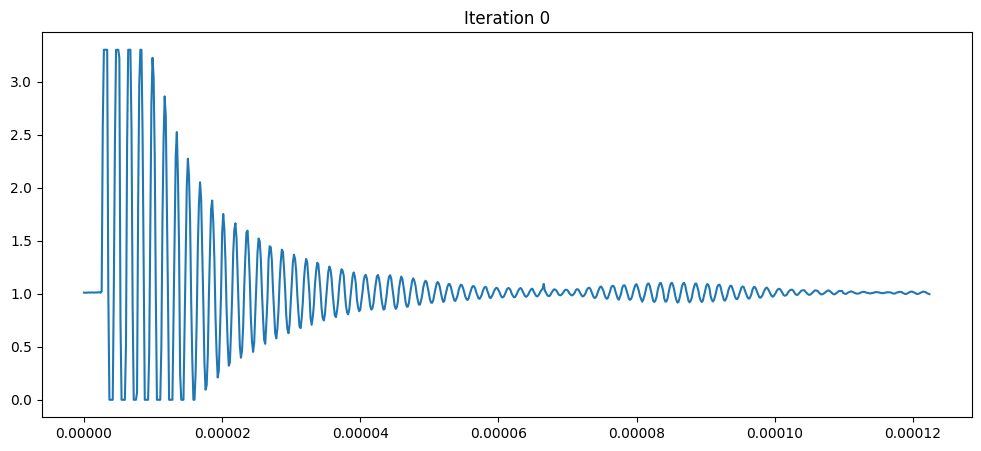

In [10]:
data = pd.read_csv('data_3-5/5_channel_v1.csv')

# 6.25 mHz sampling rate, 12 bit resolution, 3.3v reference voltage, 5 channels
time = np.arange(len(data)) * (1/6250000)  # time vector based on sampling rate

data = data * (3.3 / 4095)  # convert to voltage

# plot iteration_0 
plt.figure(figsize=(12, 5))
plt.plot(time, data['iteration_0'], label='iteration_0')
plt.title('Iteration 0')

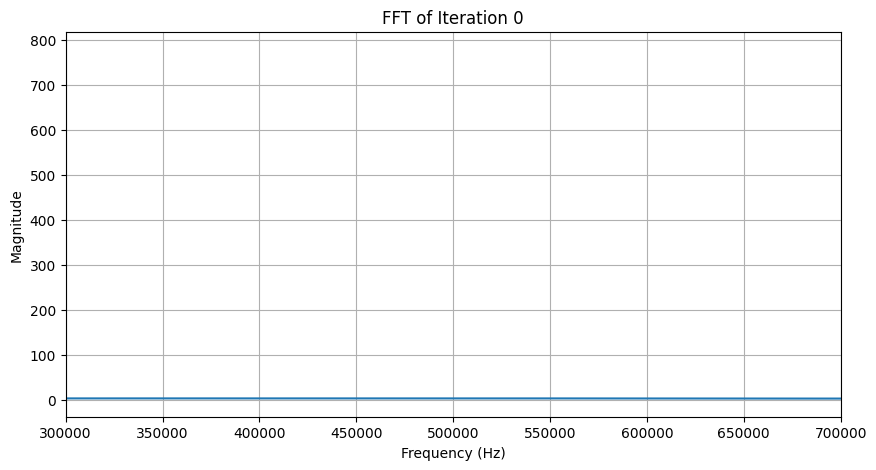

Peak frequency: -32637.07571801567 Hz


In [4]:
# plot an fft of iteration_0
fft_result = np.fft.fft(data['iteration_0'])
fft_freq = np.fft.fftfreq(len(data), d=1/6250000)
plt.figure(figsize=(10, 5))
plt.plot(fft_freq[:len(fft_freq)//2], np.abs(fft_result)[:len(fft_result)//2])
plt.title('FFT of Iteration 0')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(300_000, 700_000)  # limit x-axis to 100 kHz
plt.grid()
plt.show()

# peak at
peak_freq = fft_freq[np.argmax(np.abs(fft_result[30:1000])) + 30]  # ignore the first 30 frequencies to avoid DC component
print(f'Peak frequency: {peak_freq} Hz')

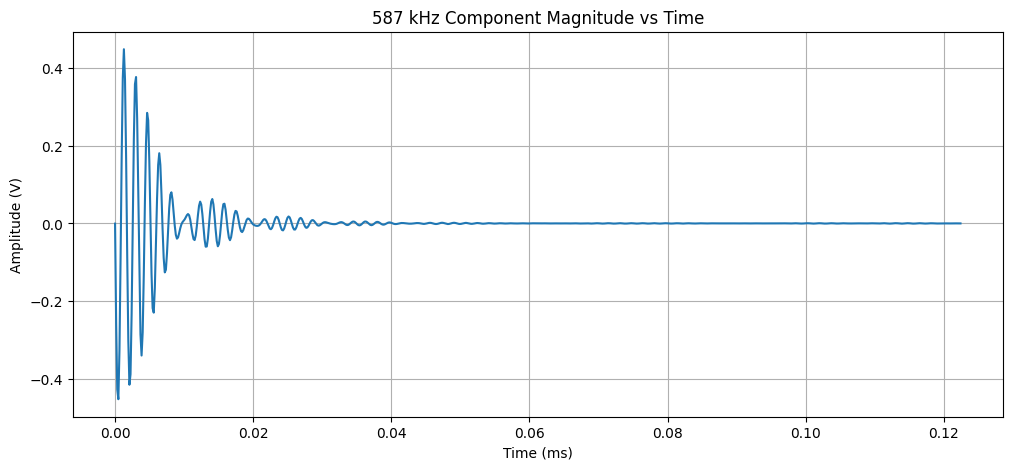

In [5]:
from scipy.signal import butter, sosfiltfilt, hilbert

# Bandpass filter around 587 kHz
f_center = 587_000  
bw = 100_000  # ±25 kHz bandwidth
fs = 6_250_000
sos = butter(4, [f_center - bw/2, f_center + bw/2], btype='band', fs=fs, output='sos')
filtered = sosfiltfilt(sos, data['iteration_0'])

# Extract envelope using Hilbert transform
analytic_signal = hilbert(filtered)
envelope = np.abs(analytic_signal)

# Plot magnitude vs time
plt.figure(figsize=(12, 5))
plt.plot(time * 1000, filtered)  # time in ms
plt.title('587 kHz Component Magnitude vs Time')
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude (V)')
plt.grid()
plt.show()

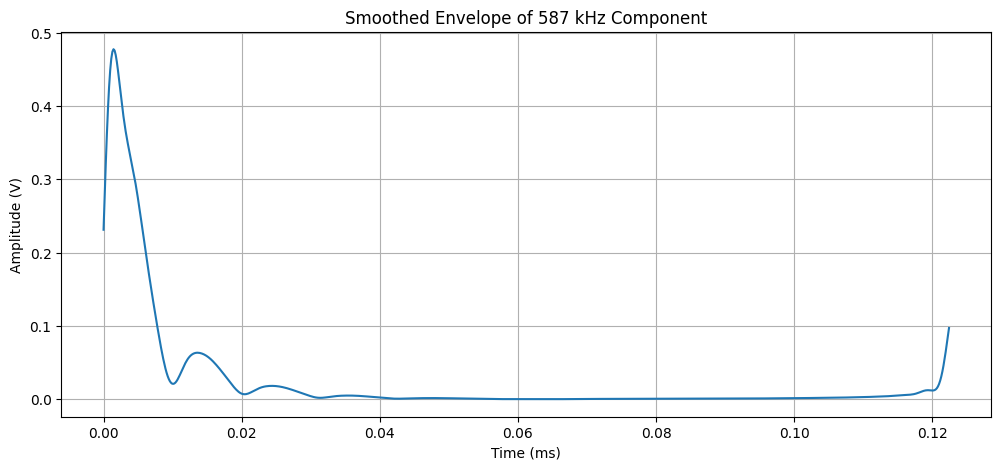

In [6]:
# low pass filter the envelope to smooth it
sos_lp = butter(4, 300_000, btype='low', fs=fs, output='sos')  # low-pass filter with 10 kHz cutoff  
envelope_lp = sosfiltfilt(sos_lp, envelope)
# plot the smoothed envelope
plt.figure(figsize=(12, 5))
plt.plot(time * 1000, envelope_lp)  # time in ms
plt.title('Smoothed Envelope of 587 kHz Component')
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude (V)')
plt.grid()
plt.show()

Text(0, 0.5, 'Depth (m)')

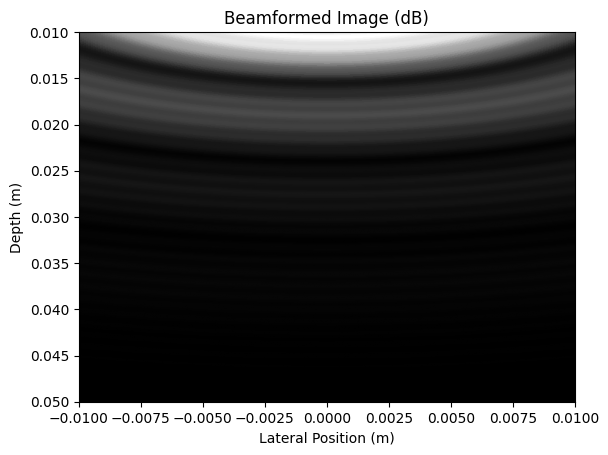

In [7]:
img, env_db, x_el = das_beamform(
    envelope[:, np.newaxis],
    fs,
    c=1540.0,
    x_el=np.array([0.0]),
    x_img=np.linspace(-0.01, 0.01, 500),
    z_img=np.linspace(0.01, 0.05, 500),
)
plt.figure()
plt.imshow(img, extent=[-0.01, 0.01, 0.05, 0.01], aspect="auto", cmap="gray")
plt.title("Beamformed Image (dB)")
plt.xlabel("Lateral Position (m)")
plt.ylabel("Depth (m)") 